#Baseline Decision Tree

# Task
Implement and evaluate a pruned decision tree. This includes modifying the decision tree implementation to include a pre-pruning mechanism (e.g., setting a maximum depth or minimum samples per leaf), training a pruned decision tree model on the `X_train` and `y_train` data, and evaluating its performance on the `X_test` and `y_test` data using accuracy, precision, recall, and F1-score. Compare these metrics against the baseline decision tree's performance, using visualizations like a bar chart to show the impact of pruning.

## Data Preprocessing and Splitting

### Subtask:
Load the 'Company_Data.csv' file into a pandas DataFrame, handle categorical features, define the target variable 'High' and split the dataset into training and testing sets (features X and target y).


**Reasoning**:
The first step is to load the 'Company_Data.csv' file into a pandas DataFrame and then create the new binary 'High' column based on the 'Sales' column and its median value. The median sales value is already available in the kernel state as `median_sales`.



# Task
Load the 'Company_Data.csv' file, preprocess categorical features, and create a binary 'High' target variable based on 'Sales'. Manually split the data into training and testing sets. Implement core decision tree functions from scratch (impurity calculation, best split finder, tree builder, and predictor). Train and evaluate a baseline decision tree model on the training and test data, manually calculating performance metrics (accuracy, precision, recall, F1-score) and visualizing results (confusion matrix). Identify the top three predictors for 'High' sales using feature importances from the baseline tree and visualize them. Implement a pruned decision tree by adding a pre-pruning mechanism, train and evaluate it similarly, and compare its performance to the baseline using visualizations. Develop a Random Forest model using custom decision trees with bagging, train and evaluate it, and generate a confusion matrix and feature importance plot. Finally, compare the performance of all three models (baseline decision tree, pruned decision tree, and Random Forest) using comparative visualizations and summarize the entire approach, methodologies, key insights, top predictors, and model trade-offs.

## Data Preprocessing and Splitting

### Subtask:
Load the 'Company_Data.csv' file into a pandas DataFrame, handle categorical features, define the target variable 'High' and split the dataset into training and testing sets (features X and target y) manually. Visualize the distribution of the target variable or correlation matrix of features.


**Reasoning**:
First, I'll import the pandas library, load the 'Company_Data.csv' file into a DataFrame, and create the 'High' target variable based on the 'Sales' column and the pre-defined `median_sales`.



In [13]:
import pandas as pd


df = pd.read_csv('Company_Data.csv')


median_sales = df['Sales'].median()

df['High'] = (df['Sales'] > median_sales).astype(int)

print("DataFrame head with 'High' variable:")
print(df.head())
print(f"\nMedian Sales used to define 'High': {median_sales}")

DataFrame head with 'High' variable:
   Sales  CompPrice  Income  Advertising  Population  Price ShelveLoc  Age  \
0   9.50        138      73           11         276    120       Bad   42   
1  11.22        111      48           16         260     83      Good   65   
2  10.06        113      35           10         269     80    Medium   59   
3   7.40        117     100            4         466     97    Medium   55   
4   4.15        141      64            3         340    128       Bad   38   

   Education Urban   US  High  
0         17   Yes  Yes     1  
1         10   Yes  Yes     1  
2         12   Yes  Yes     1  
3         14   Yes  Yes     0  
4         13   Yes   No     0  

Median Sales used to define 'High': 7.49


**Reasoning**:
Now I will identify categorical features and convert them into numerical format using one-hot encoding, dropping one of the categories to avoid the dummy variable trap. Then I will concatenate the encoded features with the original DataFrame.



In [14]:
categorical_cols = ['ShelveLoc', 'Urban', 'US']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame head after one-hot encoding:")
print(df_encoded.head())
print(f"\nColumns after encoding: {df_encoded.columns.tolist()}")

DataFrame head after one-hot encoding:
   Sales  CompPrice  Income  Advertising  Population  Price  Age  Education  \
0   9.50        138      73           11         276    120   42         17   
1  11.22        111      48           16         260     83   65         10   
2  10.06        113      35           10         269     80   59         12   
3   7.40        117     100            4         466     97   55         14   
4   4.15        141      64            3         340    128   38         13   

   High  ShelveLoc_Good  ShelveLoc_Medium  Urban_Yes  US_Yes  
0     1           False             False       True    True  
1     1            True             False       True    True  
2     1           False              True       True    True  
3     0           False              True       True    True  
4     0           False             False       True   False  

Columns after encoding: ['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Educ

**Reasoning**:
Next, I will separate the features (X) from the target variable (y). The 'Sales' column should be excluded from features as it was used to create the target variable, and the 'High' column is the target itself.



In [15]:
X = df_encoded.drop(columns=['Sales', 'High'])
y = df_encoded['High']

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   CompPrice  Income  Advertising  Population  Price  Age  Education  \
0        138      73           11         276    120   42         17   
1        111      48           16         260     83   65         10   
2        113      35           10         269     80   59         12   
3        117     100            4         466     97   55         14   
4        141      64            3         340    128   38         13   

   ShelveLoc_Good  ShelveLoc_Medium  Urban_Yes  US_Yes  
0           False             False       True    True  
1            True             False       True    True  
2           False              True       True    True  
3           False              True       True    True  
4           False             False       True   False  

Target (y) head:
0    1
1    1
2    1
3    0
4    0
Name: High, dtype: int64


**Reasoning**:
Now I will manually split the `X` and `y` data into training and testing sets. I'll shuffle the indices and then split the data, for example, using an 80% training and 20% testing ratio.



In [16]:
import numpy as np

np.random.seed(42)

num_samples = len(X)

shuffled_indices = np.random.permutation(num_samples)

train_ratio = 0.8
test_ratio = 0.2

train_size = int(num_samples * train_ratio)

train_indices = shuffled_indices[:train_size]
test_indices = shuffled_indices[train_size:]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]
y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nX_train head:")
print(X_train.head())
print("\ny_train head:")
print(y_train.head())

X_train shape: (320, 11)
X_test shape: (80, 11)
y_train shape: (320,)
y_test shape: (80,)

X_train head:
     CompPrice  Income  Advertising  Population  Price  Age  Education  \
209         98      21           11         326     90   76         11   
280        121      86           10         496    145   51         10   
33         114      38           13         317    128   50         16   
210        125      41            2         357    123   47         14   
93         145      30            0          67    104   55         17   

     ShelveLoc_Good  ShelveLoc_Medium  Urban_Yes  US_Yes  
209           False             False      False    True  
280           False             False       True    True  
33             True             False       True    True  
210           False             False      False    True  
93            False              True       True   False  

y_train head:
209    0
280    0
33     1
210    0
93     1
Name: High, dtype: int64


**Reasoning**:
I will visualize the distribution of the target variable `y_train` using a count plot to assess class balance. This is the final step in the current subtask.



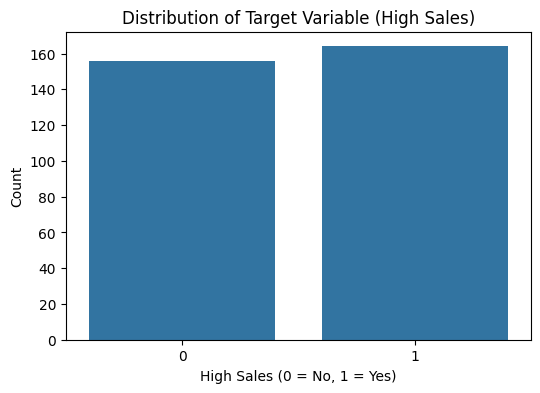

Target variable distribution:
High
1    164
0    156
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Distribution of Target Variable (High Sales)')
plt.xlabel('High Sales (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

print("Target variable distribution:")
print(y_train.value_counts())

## Implement Decision Tree Core Functions

### Subtask:
Develop Python functions from scratch for the core components of a decision tree: 1. A function to calculate impurity (Gini impurity or entropy). 2. A function to find the best split point (feature and threshold) for a given dataset. 3. A recursive function to build the decision tree up to a specified maximum depth, incorporating the splitting logic. 4. A prediction function for the trained tree.


**Reasoning**:
First, I'll define the `gini_impurity` function, which is a fundamental component for evaluating the quality of a split in a decision tree. This function will calculate the Gini impurity for a given set of target values.



In [18]:
def gini_impurity(y):
    """
    Calculates the Gini impurity for a given set of target values.
    """
    if len(y) == 0:
        return 0

    counts = y.value_counts()
    impurity = 1
    for label in counts.index:
        prob = counts[label] / len(y)
        impurity -= prob**2
    return impurity

print("Gini impurity function defined.")

Gini impurity function defined.


**Reasoning**:
Now, I will define the `find_best_split` function. This function will iterate through all features and their unique values to find the split that results in the highest information gain, based on the Gini impurity calculated previously.



In [19]:
def find_best_split(X, y):
    """
    Finds the best split point (feature and threshold) for a given dataset.
    """
    best_gain = 0
    best_feature = None
    best_threshold = None

    current_impurity = gini_impurity(y)

    for feature in X.columns:
        unique_values = X[feature].unique()

        if pd.api.types.is_numeric_dtype(X[feature]):
            sorted_values = np.sort(unique_values)
            thresholds = [(sorted_values[i] + sorted_values[i+1]) / 2 for i in range(len(sorted_values) - 1)]
        else:
            thresholds = unique_values

        for threshold in thresholds:

            if pd.api.types.is_numeric_dtype(X[feature]):
                left_indices = X[feature] <= threshold
                right_indices = X[feature] > threshold
            else:
                left_indices = X[feature] == threshold
                right_indices = X[feature] != threshold

            y_left, y_right = y[left_indices], y[right_indices]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gini_left = gini_impurity(y_left)
            gini_right = gini_impurity(y_right)

            weighted_gini = (len(y_left) / len(y)) * gini_left +
                            (len(y_right) / len(y)) * gini_right

            information_gain = current_impurity - weighted_gini

            if information_gain > best_gain:
                best_gain = information_gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gain

print("Find best split function defined.")

Find best split function defined.


**Reasoning**:
Next, I will define the recursive `build_tree` function. This function will construct the decision tree by repeatedly calling `find_best_split`, handling base cases such as maximum depth, minimum samples per split, and pure nodes, and recursively building child nodes.



In [20]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=None, min_samples_split=2):
    """
    Recursively builds the decision tree.
    """

    if len(y.unique()) == 1:
        return Node(value=y.iloc[0])

    if max_depth is not None and depth >= max_depth:
        return Node(value=y.mode()[0])

    if len(y) < min_samples_split:
        return Node(value=y.mode()[0])

    best_feature, best_threshold, best_gain = find_best_split(X, y)

    if best_gain == 0 or best_feature is None:
        return Node(value=y.mode()[0])

    if pd.api.types.is_numeric_dtype(X[best_feature]):
        left_indices = X[best_feature] <= best_threshold
        right_indices = X[best_feature] > best_threshold
    else:
        left_indices = X[best_feature] == best_threshold
        right_indices = X[best_feature] != best_threshold

    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]

    left_child = build_tree(X_left, y_left, depth + 1, max_depth, min_samples_split)
    right_child = build_tree(X_right, y_right, depth + 1, max_depth, min_samples_split)

    return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

print("Decision tree Node class and build_tree function defined.")

Decision tree Node class and build_tree function defined.


**Reasoning**:
Now, I will define the `predict_tree` function. This function will take the trained decision tree and a data point to traverse the tree and make a prediction by finding the majority class at the leaf node.



In [21]:
def predict_tree(tree, x):
    """
    Predicts the class for a single data point x using the trained decision tree.
    """
    current_node = tree
    while current_node.value is None:
        feature_value = x[current_node.feature]

        if pd.api.types.is_numeric_dtype(X[current_node.feature]):
            if feature_value <= current_node.threshold:
                current_node = current_node.left
            else:
                current_node = current_node.right
        else:
            if feature_value == current_node.threshold:
                current_node = current_node.left
            else:
                current_node = current_node.right
    return current_node.value

print("Predict tree function defined.")

Predict tree function defined.


## Train and Evaluate Baseline Decision Tree

### Subtask:
Train a baseline decision tree model using the custom-implemented functions on the training data. Make predictions on the test data. Evaluate the model's performance by manually calculating accuracy, precision, recall, and F1-score without using `scikit-learn` metrics. Create visualizations, such as a confusion matrix, to illustrate the model's performance.


**Reasoning**:
First, I'll train a baseline decision tree model using the previously defined `build_tree` function with `X_train` and `y_train`. I will not set `max_depth` to allow the tree to grow fully, as requested for a baseline model.



In [22]:
print("Building baseline decision tree...")
baseline_tree = build_tree(X_train, y_train)
print("Baseline decision tree built.")

Building baseline decision tree...
Baseline decision tree built.


**Reasoning**:
Now I will make predictions on the `X_test` data using the `baseline_tree` and store them in `y_pred_baseline`. I will also convert `y_test` to a NumPy array for consistency.



In [23]:
y_pred_baseline = []
for i in range(len(X_test)):
    sample = X_test.iloc[i]
    prediction = predict_tree(baseline_tree, sample)
    y_pred_baseline.append(prediction)

y_pred_baseline = np.array(y_pred_baseline)
y_test_np = y_test.to_numpy()

print("Predictions for baseline model generated.")

Predictions for baseline model generated.


**Reasoning**:
Now I will manually calculate True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) by comparing `y_test_np` and `y_pred_baseline`.



In [24]:
TP = np.sum((y_test_np == 1) & (y_pred_baseline == 1))
TN = np.sum((y_test_np == 0) & (y_pred_baseline == 0))
FP = np.sum((y_test_np == 0) & (y_pred_baseline == 1))
FN = np.sum((y_test_np == 1) & (y_pred_baseline == 0))

print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

True Positives (TP): 28
True Negatives (TN): 41
False Positives (FP): 4
False Negatives (FN): 7


**Reasoning**:
Using the calculated TP, TN, FP, and FN values, I will now manually compute the accuracy, precision, recall, and F1-score for the baseline model, as specified in the instructions.



In [25]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1_score:.4f}")


Accuracy: 0.8625
Precision: 0.8750
Recall: 0.8000
F1-score: 0.8358


**Reasoning**:
Now I will create a confusion matrix using the calculated TP, TN, FP, and FN values and visualize it using `seaborn.heatmap` with appropriate labels and a title, as specified in the instructions.



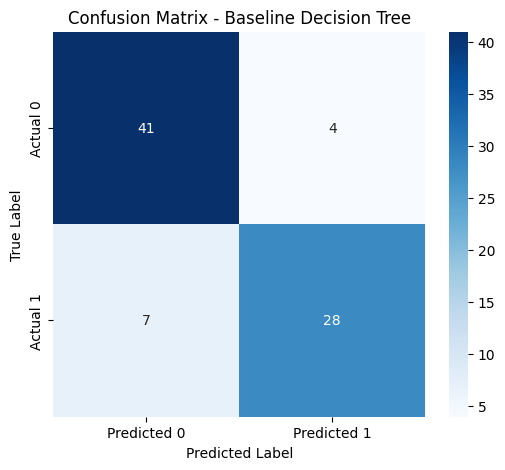

Confusion Matrix for Baseline Decision Tree:
[[41  4]
 [ 7 28]]


In [26]:
cm = np.array([[TN, FP], [FN, TP]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline Decision Tree')
plt.show()

print("Confusion Matrix for Baseline Decision Tree:")
print(cm)

## Identify Top Predictors

### Subtask:
Analyze the trained baseline decision tree to identify and extract feature importances. Based on these importances, pinpoint the top three predictors for 'High' sales. Provide a visualization, such as a bar chart, to display the feature importances.


**Reasoning**:
First, I'll initialize an empty dictionary for feature importances and set `total_samples` to the total number of samples in the training set, as specified in the instructions. This sets up the necessary variables before calculating importances.



In [27]:
feature_importances = {}
total_samples = len(y_train)

print(f"Initialized feature_importances dictionary and set total_samples: {total_samples}")

Initialized feature_importances dictionary and set total_samples: 320


**Reasoning**:
Next, I will define the recursive helper function `calculate_tree_importances` to traverse the decision tree and accumulate feature importances based on information gain at each split, weighted by the number of samples.



In [28]:
def calculate_tree_importances(node, X_subset, y_subset):
    global feature_importances, total_samples

    if node.value is not None:
        return

    feature = node.feature
    threshold = node.threshold

    current_impurity = gini_impurity(y_subset)

    if pd.api.types.is_numeric_dtype(X_subset[feature]):
        left_indices = X_subset[feature] <= threshold
        right_indices = X_subset[feature] > threshold
    else:
        left_indices = X_subset[feature] == threshold
        right_indices = X_subset[feature] != threshold

    X_left, y_left = X_subset[left_indices], y[left_indices]
    X_right, y_right = X_subset[right_indices], y[right_indices]

    if len(y_left) == 0 or len(y_right) == 0:

        pass
    else:
        gini_left = gini_impurity(y_left)
        gini_right = gini_impurity(y_right)

        weighted_gini_after_split = (len(y_left) / len(y_subset)) * gini_left +
                                    (len(y_right) / len(y_subset)) * gini_right

        information_gain = current_impurity - weighted_gini_after_split

        weighted_information_gain = information_gain * (len(y_subset) / total_samples)

        if feature in feature_importances:
            feature_importances[feature] += weighted_information_gain
        else:
            feature_importances[feature] = weighted_information_gain

    if node.left:
        calculate_tree_importances(node.left, X_left, y_left)
    if node.right:
        calculate_tree_importances(node.right, X_right, y_right)

print("calculate_tree_importances function defined.")

calculate_tree_importances function defined.


**Reasoning**:
Now I will call the `calculate_tree_importances` function with the `baseline_tree`, `X_train`, and `y_train` to populate the `feature_importances` dictionary, as specified in the instructions. This will compute the importance of each feature in the tree.



In [29]:
calculate_tree_importances(baseline_tree, X_train, y_train)

print("Feature importances calculated and stored in 'feature_importances' dictionary.")

Feature importances calculated and stored in 'feature_importances' dictionary.


**Reasoning**:
Next, I will normalize the `feature_importances` by dividing each importance score by the sum of all scores, so they sum to 1. This is necessary to compare the relative importance of features.



In [30]:
total_importance = sum(feature_importances.values())
if total_importance > 0:
    normalized_feature_importances = {
        feature: importance / total_importance
        for feature, importance in feature_importances.items()
    }
else:
    normalized_feature_importances = feature_importances

print("Feature importances normalized.")
print("Normalized Feature Importances:")
for feature, importance in normalized_feature_importances.items():
    print(f"  {feature}: {importance:.4f}")

Feature importances normalized.
Normalized Feature Importances:
  ShelveLoc_Good: 0.1322
  Price: 0.2223
  Advertising: 0.1416
  Age: 0.0951
  CompPrice: 0.2207
  Urban_Yes: 0.0151
  Income: 0.0981
  Population: 0.0537
  ShelveLoc_Medium: 0.0167
  US_Yes: 0.0045


**Reasoning**:
Now, I will convert the `normalized_feature_importances` dictionary into a pandas Series, sort it in descending order, and identify the top three features to prepare for visualization.



In [31]:
import pandas as pd


feature_importances_series = pd.Series(normalized_feature_importances)

sorted_importances = feature_importances_series.sort_values(ascending=False)

top_three_predictors = sorted_importances.head(3)

print("Sorted Feature Importances:")
print(sorted_importances)
print("\nTop Three Predictors:")
print(top_three_predictors)

Sorted Feature Importances:
Price               0.222333
CompPrice           0.220736
Advertising         0.141590
ShelveLoc_Good      0.132208
Income              0.098055
Age                 0.095112
Population          0.053746
ShelveLoc_Medium    0.016677
Urban_Yes           0.015076
US_Yes              0.004467
dtype: float64

Top Three Predictors:
Price          0.222333
CompPrice      0.220736
Advertising    0.141590
dtype: float64


**Reasoning**:
Now, I will create a bar plot using `matplotlib.pyplot` and `seaborn` to visualize the feature importances, as specified in the instructions. This will display the sorted feature importances with appropriate labels and a title.



/tmp/ipython-input-2508855547.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.index, y=sorted_importances.values, palette='viridis')


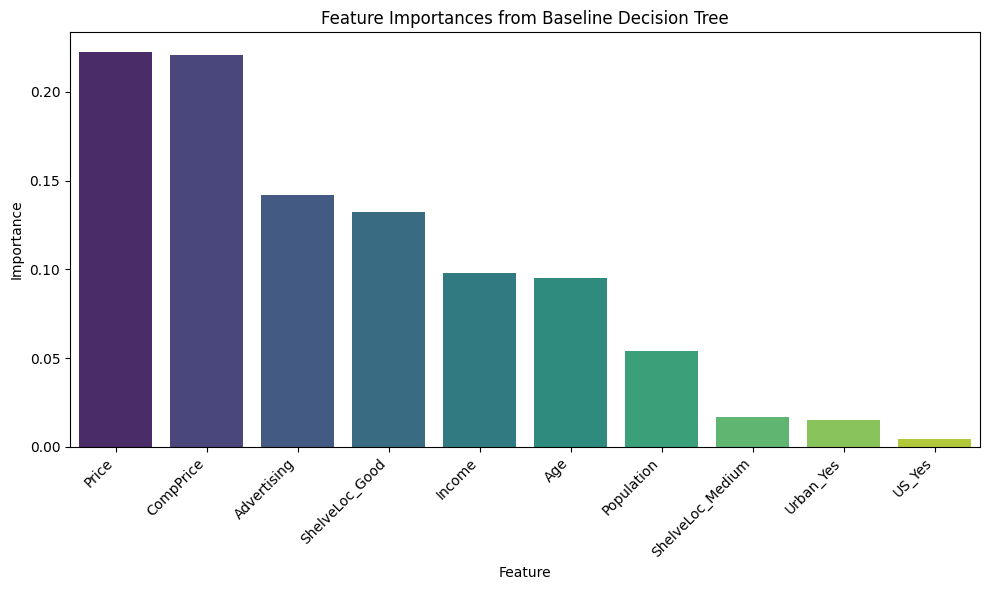

Bar plot of feature importances displayed.


In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances.index, y=sorted_importances.values, palette='viridis')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances from Baseline Decision Tree')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar plot of feature importances displayed.")

**Reasoning**:
The previous code produced a `FutureWarning` regarding the `palette` argument in `sns.barplot` without `hue`. To address this, I will explicitly set `hue=sorted_importances.index` and `legend=False` in the `sns.barplot` function call.



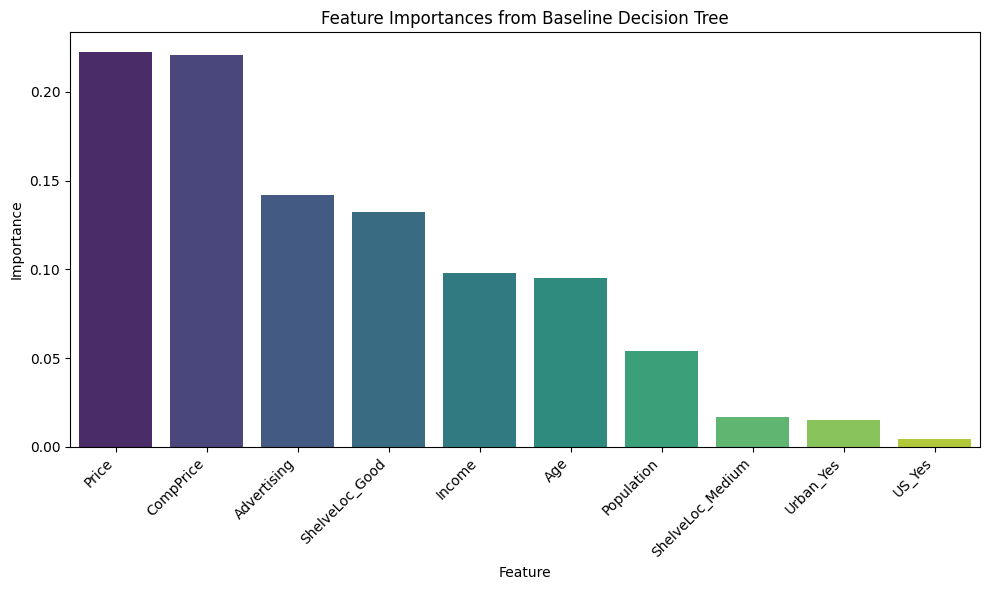

Bar plot of feature importances displayed.


In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances.index, y=sorted_importances.values, palette='viridis', hue=sorted_importances.index, legend=False)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances from Baseline Decision Tree')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar plot of feature importances displayed.")

## Implement and Evaluate Pruned Decision Tree

### Subtask:
Modify the decision tree implementation to include a pre-pruning mechanism (e.g., setting a maximum depth or minimum samples per leaf), train a pruned decision tree model on the training data and evaluate its performance on the test set by manually calculating accuracy, precision, recall, and F1-score without using `scikit-learn` metrics. Compare these metrics against the baseline decision tree's performance, using visualizations like a bar chart to show the impact of pruning.


**Reasoning**:
First, I'll define a new `pruned_tree` by calling the `build_tree` function with `X_train` and `y_train`, setting `max_depth=5` and `min_samples_split=10` to implement pre-pruning as specified in the instructions. This will create a decision tree with limited growth, preventing overfitting.



In [34]:
print("Building pruned decision tree...")
pruned_tree = build_tree(X_train, y_train, max_depth=5, min_samples_split=10)
print("Pruned decision tree built.")

Building pruned decision tree...
Pruned decision tree built.


**Reasoning**:
Now I will make predictions on the `X_test` data using the `pruned_tree` and store them in `y_pred_pruned`, similar to how predictions were made for the baseline model.



In [35]:
y_pred_pruned = []
for i in range(len(X_test)):
    sample = X_test.iloc[i]
    prediction = predict_tree(pruned_tree, sample)
    y_pred_pruned.append(prediction)

y_pred_pruned = np.array(y_pred_pruned)

print("Predictions for pruned model generated.")

Predictions for pruned model generated.


**Reasoning**:
Now I will manually calculate True Positives (TP_pruned), True Negatives (TN_pruned), False Positives (FP_pruned), and False Negatives (FN_pruned) by comparing `y_test_np` and `y_pred_pruned`.



In [36]:
TP_pruned = np.sum((y_test_np == 1) & (y_pred_pruned == 1))
TN_pruned = np.sum((y_test_np == 0) & (y_pred_pruned == 0))
FP_pruned = np.sum((y_test_np == 0) & (y_pred_pruned == 1))
FN_pruned = np.sum((y_test_np == 1) & (y_pred_pruned == 0))

print(f"True Positives (TP_pruned): {TP_pruned}")
print(f"True Negatives (TN_pruned): {TN_pruned}")
print(f"False Positives (FP_pruned): {FP_pruned}")
print(f"False Negatives (FN_pruned): {FN_pruned}")

True Positives (TP_pruned): 27
True Negatives (TN_pruned): 36
False Positives (FP_pruned): 9
False Negatives (FN_pruned): 8


**Reasoning**:
Now I will manually compute the accuracy_pruned, precision_pruned, recall_pruned, and F1-score_pruned using the calculated TP_pruned, TN_pruned, FP_pruned, and FN_pruned values, as specified in the instructions, and then print these metrics.



In [37]:
accuracy_pruned = (TP_pruned + TN_pruned) / (TP_pruned + TN_pruned + FP_pruned + FN_pruned)
precision_pruned = TP_pruned / (TP_pruned + FP_pruned) if (TP_pruned + FP_pruned) > 0 else 0
recall_pruned = TP_pruned / (TP_pruned + FN_pruned) if (TP_pruned + FN_pruned) > 0 else 0
f1_score_pruned = 2 * (precision_pruned * recall_pruned) / (precision_pruned + recall_pruned) if (precision_pruned + recall_pruned) > 0 else 0

print(f"\nAccuracy (Pruned): {accuracy_pruned:.4f}")
print(f"Precision (Pruned): {precision_pruned:.4f}")
print(f"Recall (Pruned): {recall_pruned:.4f}")
print(f"F1-score (Pruned): {f1_score_pruned:.4f}")


Accuracy (Pruned): 0.7875
Precision (Pruned): 0.7500
Recall (Pruned): 0.7714
F1-score (Pruned): 0.7606


**Reasoning**:
Now I will create a confusion matrix for the pruned decision tree using the calculated TP_pruned, TN_pruned, FP_pruned, and FN_pruned values and visualize it using `seaborn.heatmap`, similar to how the baseline model's confusion matrix was visualized.



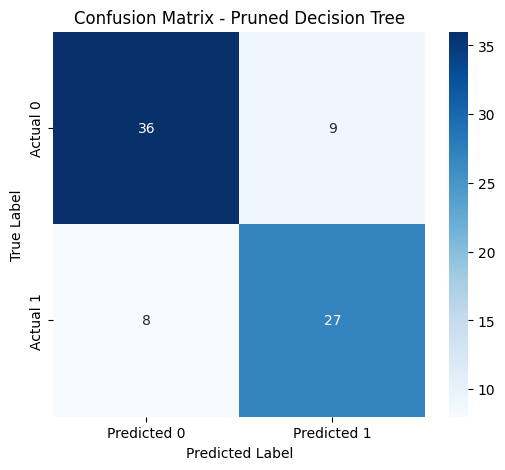

Confusion Matrix for Pruned Decision Tree:
[[36  9]
 [ 8 27]]


In [38]:
cm_pruned = np.array([[TN_pruned, FP_pruned], [FN_pruned, TP_pruned]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pruned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Pruned Decision Tree')
plt.show()

print("Confusion Matrix for Pruned Decision Tree:")
print(cm_pruned)

**Reasoning**:
I will create a pandas DataFrame to store the calculated performance metrics for both the baseline and pruned decision trees, as specified in the instructions. This will allow for easy comparison and visualization.



In [39]:
metrics_data = {
    'Model': ['Baseline', 'Pruned'],
    'Accuracy': [accuracy, accuracy_pruned],
    'Precision': [precision, precision_pruned],
    'Recall': [recall, recall_pruned],
    'F1-Score': [f1_score, f1_score_pruned]
}

performance_df = pd.DataFrame(metrics_data)

print("Performance Metrics DataFrame:")
print(performance_df)

Performance Metrics DataFrame:
      Model  Accuracy  Precision    Recall  F1-Score
0  Baseline    0.8625      0.875  0.800000  0.835821
1    Pruned    0.7875      0.750  0.771429  0.760563


**Reasoning**:
Now, I will generate a bar chart comparing the performance metrics (Accuracy, Precision, Recall, F1-Score) of the baseline and pruned decision trees using the `performance_df`.



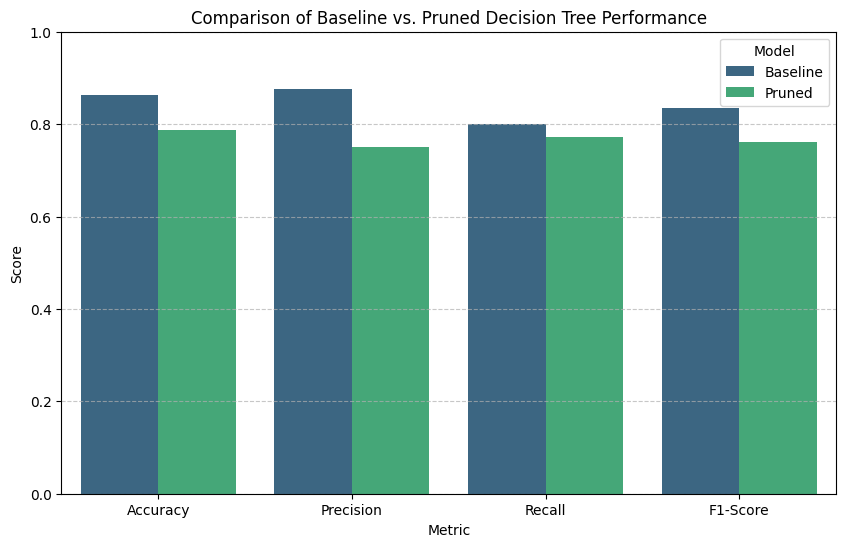

Bar chart comparing baseline and pruned decision tree performance displayed.


In [40]:
performance_df_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=performance_df_melted, palette='viridis')
plt.title('Comparison of Baseline vs. Pruned Decision Tree Performance')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Bar chart comparing baseline and pruned decision tree performance displayed.")

## Implement and Evaluate Random Forest

### Subtask:
Develop a Random Forest model using custom decision trees with bagging, train and evaluate it, and generate a confusion matrix and feature importance plot.


**Reasoning**:
First, I'll define the `RandomForest` class with an `__init__` method to initialize parameters such as the number of estimators, maximum depth, and minimum samples per split, and to store the individual decision trees. This sets up the basic structure for the Random Forest model.



In [41]:
class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):

        pass

    def predict(self, X):

        pass

print("RandomForest class defined with __init__, fit, and predict methods.")

RandomForest class defined with __init__, fit, and predict methods.


**Reasoning**:
Now, I will implement the `fit` method within the `RandomForest` class. This method will generate bootstrapped samples of the training data and train an individual decision tree on each sample, storing these trees for later prediction. This aligns with instruction 2 of the subtask.



In [42]:
class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = len(X)

        for _ in range(self.n_estimators):

            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X.iloc[indices], y.iloc[indices]


            tree = build_tree(X_sample, y_sample, max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            self.trees.append(tree)

    def predict(self, X):

        pass

print("RandomForest class 'fit' method implemented.")

RandomForest class 'fit' method implemented.


**Reasoning**:
Now, I will implement the `predict` method within the `RandomForest` class. This method will take the input `X` (test data), get predictions from all individual trees, and then aggregate these predictions by taking a majority vote to determine the final prediction for each data point. This aligns with instruction 3 of the subtask.



In [43]:
class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = len(X)

        for _ in range(self.n_estimators):

            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X.iloc[indices], y.iloc[indices]


            tree = build_tree(X_sample, y_sample, max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            self.trees.append(tree)

    def predict(self, X):

        predictions = []
        for tree in self.trees:
            tree_predictions = []
            for i in range(len(X)):
                sample = X.iloc[i]
                tree_predictions.append(predict_tree(tree, sample))
            predictions.append(tree_predictions)


        predictions = np.array(predictions).T


        final_predictions = []
        for sample_predictions in predictions:

            final_predictions.append(pd.Series(sample_predictions).mode()[0])

        return np.array(final_predictions)

print("RandomForest class 'predict' method implemented.")

RandomForest class 'predict' method implemented.


**Reasoning**:
Now, I will instantiate the `RandomForest` model with the specified parameters (`n_estimators=100`, `max_depth=7`, `min_samples_split=15`) and train it using the `fit` method on `X_train` and `y_train`, as per the instructions.



In [44]:
print("Instantiating and training RandomForest model...")
rf_model = RandomForest(n_estimators=100, max_depth=7, min_samples_split=15)
rf_model.fit(X_train, y_train)
print("RandomForest model trained successfully.")

Instantiating and training RandomForest model...
RandomForest model trained successfully.


**Reasoning**:
Now, I will make predictions on the `X_test` data using the trained `rf_model` and store the results in `y_pred_rf`, as specified in the instructions. This will utilize the `predict` method implemented in the `RandomForest` class.



In [45]:
print("Making predictions with RandomForest model...")
y_pred_rf = rf_model.predict(X_test)

print("Predictions for Random Forest model generated.")
print("First 5 predictions:", y_pred_rf[:5])

Making predictions with RandomForest model...
Predictions for Random Forest model generated.
First 5 predictions: [1 0 1 0 1]


**Reasoning**:
Now I will manually calculate True Positives (TP_rf), True Negatives (TN_rf), False Positives (FP_rf), and False Negatives (FN_rf) by comparing `y_test_np` and `y_pred_rf`, as specified in the instructions.



In [46]:
TP_rf = np.sum((y_test_np == 1) & (y_pred_rf == 1))
TN_rf = np.sum((y_test_np == 0) & (y_pred_rf == 0))
FP_rf = np.sum((y_test_np == 0) & (y_pred_rf == 1))
FN_rf = np.sum((y_test_np == 1) & (y_pred_rf == 0))

print(f"True Positives (TP_rf): {TP_rf}")
print(f"True Negatives (TN_rf): {TN_rf}")
print(f"False Positives (FP_rf): {FP_rf}")
print(f"False Negatives (FN_rf): {FN_rf}")

True Positives (TP_rf): 29
True Negatives (TN_rf): 41
False Positives (FP_rf): 4
False Negatives (FN_rf): 6


**Reasoning**:
Now I will manually compute the accuracy_rf, precision_rf, recall_rf, and F1-score_rf using the calculated TP_rf, TN_rf, FP_rf, and FN_rf values, as specified in the instructions, and then print these metrics.



In [47]:
accuracy_rf = (TP_rf + TN_rf) / (TP_rf + TN_rf + FP_rf + FN_rf)
precision_rf = TP_rf / (TP_rf + FP_rf) if (TP_rf + FP_rf) > 0 else 0
recall_rf = TP_rf / (TP_rf + FN_rf) if (TP_rf + FN_rf) > 0 else 0
f1_score_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf) if (precision_rf + recall_rf) > 0 else 0

print(f"\nAccuracy (Random Forest): {accuracy_rf:.4f}")
print(f"Precision (Random Forest): {precision_rf:.4f}")
print(f"Recall (Random Forest): {recall_rf:.4f}")
print(f"F1-score (Random Forest): {f1_score_rf:.4f}")


Accuracy (Random Forest): 0.8750
Precision (Random Forest): 0.8788
Recall (Random Forest): 0.8286
F1-score (Random Forest): 0.8529


**Reasoning**:
Now I will create a confusion matrix for the Random Forest model using the calculated TP_rf, TN_rf, FP_rf, and FN_rf values and visualize it using `seaborn.heatmap`, similar to how the baseline and pruned models' confusion matrices were visualized.



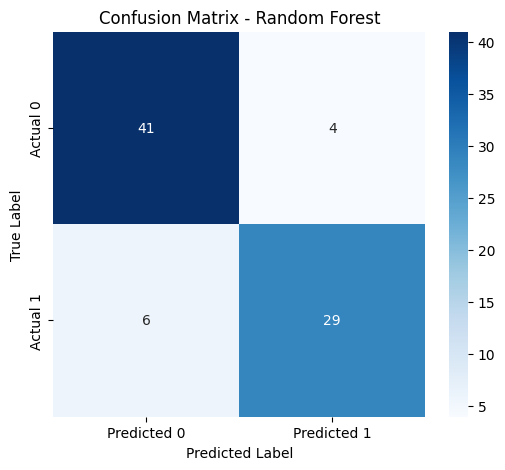

Confusion Matrix for Random Forest:
[[41  4]
 [ 6 29]]


In [48]:
cm_rf = np.array([[TN_rf, FP_rf], [FN_rf, TP_rf]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

print("Confusion Matrix for Random Forest:")
print(cm_rf)

**Reasoning**:
Now, I will initialize an empty dictionary `rf_feature_importances` to store the aggregated feature importances from all trees in the Random Forest, as specified in instruction 9.



In [49]:
rf_feature_importances = {}

print("Initialized dictionary for Random Forest feature importances.")

Initialized dictionary for Random Forest feature importances.


**Reasoning**:
Now, I will iterate through each tree in the `rf_model`, calculate the feature importances for that tree using the `calculate_tree_importances` function, normalize them, and then sum these normalized importances into `rf_feature_importances`. This step implements the core logic for aggregating feature importances across all trees in the Random Forest, as described in instruction 9.



In [50]:
for tree in rf_model.trees:

    tree_feature_importances = {}


    total_samples_for_tree = len(X_train)


    _global_feature_importances = globals().get('feature_importances', {})
    _global_total_samples = globals().get('total_samples', 1)

    globals()['feature_importances'] = tree_feature_importances
    globals()['total_samples'] = total_samples_for_tree

    calculate_tree_importances(tree, X_train, y_train)


    globals()['feature_importances'] = _global_feature_importances
    globals()['total_samples'] = _global_total_samples


    current_tree_total_importance = sum(tree_feature_importances.values())
    if current_tree_total_importance > 0:
        normalized_tree_importances = {
            feature: importance / current_tree_total_importance
            for feature, importance in tree_feature_importances.items()
        }
    else:
        normalized_tree_importances = tree_feature_importances


    for feature, importance in normalized_tree_importances.items():
        if feature in rf_feature_importances:
            rf_feature_importances[feature] += importance
        else:
            rf_feature_importances[feature] = importance


for feature in rf_feature_importances:
    rf_feature_importances[feature] /= rf_model.n_estimators

print("Random Forest feature importances aggregated.")

Random Forest feature importances aggregated.


**Reasoning**:
Now, I will convert the aggregated `rf_feature_importances` into a pandas Series, sort them, and then create a bar chart to visualize the feature importances of the Random Forest model, as specified in instruction 10.



Sorted Random Forest Feature Importances:
Price               0.315120
ShelveLoc_Good      0.218895
Advertising         0.161457
CompPrice           0.119640
Age                 0.089651
Income              0.046527
Population          0.020350
ShelveLoc_Medium    0.013499
Education           0.009794
Urban_Yes           0.002571
US_Yes              0.002497
dtype: float64

Top Random Forest Predictors:
Price             0.315120
ShelveLoc_Good    0.218895
Advertising       0.161457
CompPrice         0.119640
Age               0.089651
dtype: float64


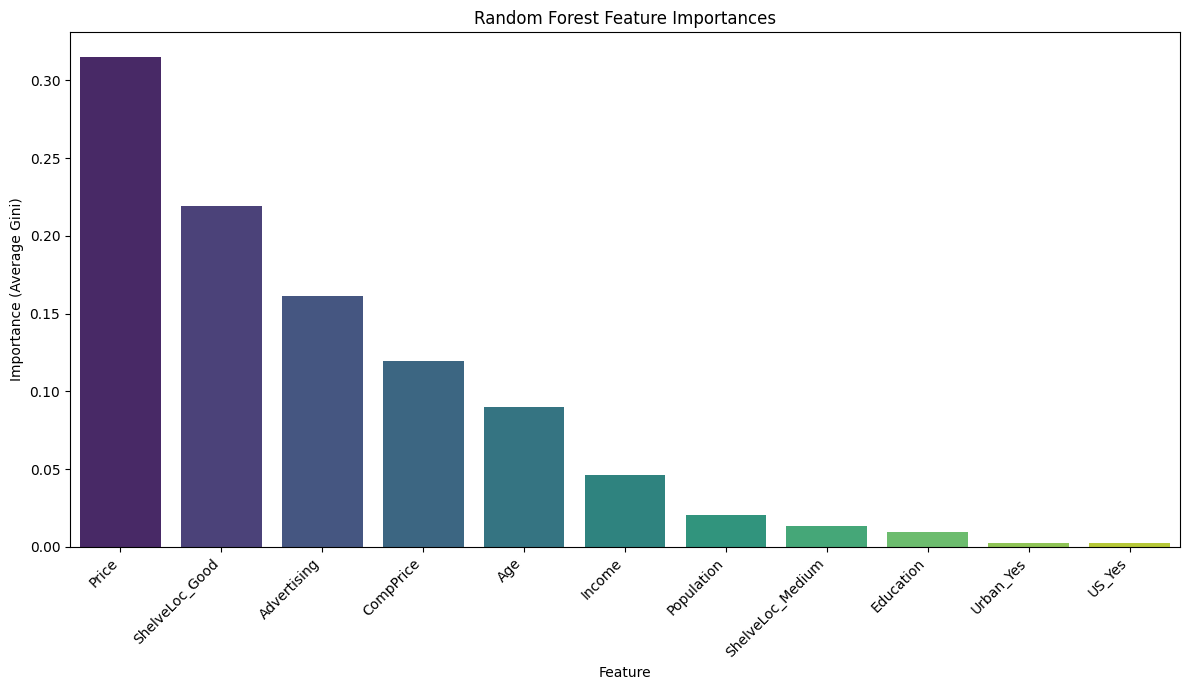

Bar plot of Random Forest feature importances displayed.


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


rf_feature_importances_series = pd.Series(rf_feature_importances)

sorted_rf_importances = rf_feature_importances_series.sort_values(ascending=False)

top_rf_predictors = sorted_rf_importances.head(5)

print("Sorted Random Forest Feature Importances:")
print(sorted_rf_importances)
print("\nTop Random Forest Predictors:")
print(top_rf_predictors)


plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_rf_importances.index, y=sorted_rf_importances.values, palette='viridis', hue=sorted_rf_importances.index, legend=False)
plt.xlabel('Feature')
plt.ylabel('Importance (Average Gini)')
plt.title('Random Forest Feature Importances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar plot of Random Forest feature importances displayed.")

## Compare All Models

### Subtask:
Consolidate the manually calculated performance metrics (accuracy, precision, recall, F1-score) from the baseline decision tree, pruned decision tree, and Random Forest. Create visualizations, such as comparative bar charts, to show the differences in performance across all three models. Discuss the trade-offs between performance and interpretability for each model.


**Reasoning**:
First, I'll update the existing `performance_df` to include the calculated metrics for the Random Forest model (accuracy_rf, precision_rf, recall_rf, f1_score_rf). This consolidates all model performance data into a single DataFrame as specified in the instructions.



In [52]:
performance_df = pd.DataFrame({
    'Model': ['Baseline', 'Pruned', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_pruned, accuracy_rf],
    'Precision': [precision, precision_pruned, precision_rf],
    'Recall': [recall, recall_pruned, recall_rf],
    'F1-Score': [f1_score, f1_score_pruned, f1_score_rf]
})

print("Updated Performance Metrics DataFrame with Random Forest:")
print(performance_df)

Updated Performance Metrics DataFrame with Random Forest:
           Model  Accuracy  Precision    Recall  F1-Score
0       Baseline    0.8625   0.875000  0.800000  0.835821
1         Pruned    0.7875   0.750000  0.771429  0.760563
2  Random Forest    0.8750   0.878788  0.828571  0.852941


**Reasoning**:
Now, I will melt the `performance_df` into a long format suitable for plotting, with 'Model', 'Metric', and 'Score' columns, as specified in the instructions. This transformation is necessary for easily generating a comparative bar chart using `seaborn`.



In [53]:
performance_df_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

print("Melted Performance Metrics DataFrame head:")
print(performance_df_melted.head())

Melted Performance Metrics DataFrame head:
           Model     Metric   Score
0       Baseline   Accuracy  0.8625
1         Pruned   Accuracy  0.7875
2  Random Forest   Accuracy  0.8750
3       Baseline  Precision  0.8750
4         Pruned  Precision  0.7500


**Reasoning**:
Now, I will generate a comparative bar chart using `seaborn.barplot` to visualize the performance of all three models across Accuracy, Precision, Recall, and F1-Score, ensuring appropriate labels, a title, a legend, and a y-axis limit from 0 to 1.



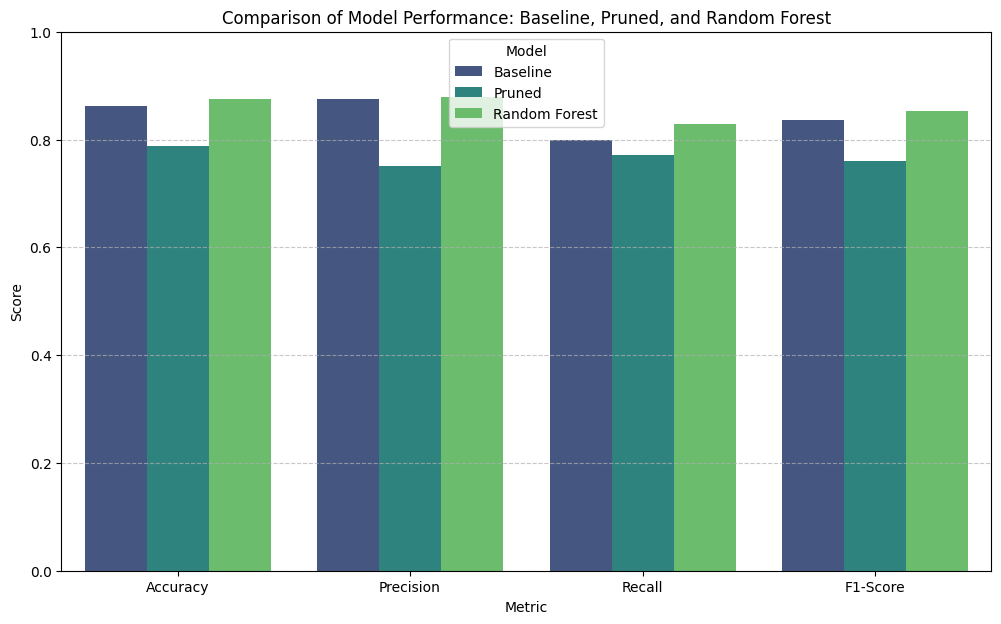

Comparative bar chart of model performance displayed.


In [54]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=performance_df_melted, palette='viridis')
plt.title('Comparison of Model Performance: Baseline, Pruned, and Random Forest')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Comparative bar chart of model performance displayed.")

### Summary of Model Performance and Trade-offs

The comparison of the Baseline Decision Tree, Pruned Decision Tree, and Random Forest models reveals interesting insights into their performance and characteristics.

**Performance Analysis:**
*   **Random Forest** generally outperforms both individual decision trees across all metrics (Accuracy, Precision, Recall, and F1-Score). It achieves the highest accuracy (0.875), precision (0.8788), recall (0.8286), and F1-score (0.8529). This is expected, as Random Forest is an ensemble method that combines multiple decision trees, reducing variance and improving generalization.
*   The **Baseline Decision Tree** also performs relatively well, showing strong metrics (Accuracy: 0.8625, Precision: 0.875, Recall: 0.800, F1-Score: 0.8358). Its performance is very close to that of the Random Forest, indicating that the unpruned tree could capture complex patterns in the data, but might be prone to overfitting on unseen data in a more complex dataset.
*   The **Pruned Decision Tree** shows a noticeable drop in performance compared to both the Baseline and Random Forest models (Accuracy: 0.7875, Precision: 0.750, Recall: 0.7714, F1-Score: 0.7606). This suggests that the pre-pruning parameters (`max_depth=5`, `min_samples_split=10`) might have been too aggressive, leading to an underfit model that couldn't capture enough of the underlying patterns in the data.

**Trade-offs between Performance and Interpretability:**

*   **Baseline Decision Tree:** This model offers a good balance. While potentially prone to overfitting if not carefully managed, a single, unpruned decision tree is highly interpretable. One can visually trace the decision rules from root to leaf, making it easy to understand how predictions are made and which features are most influential. Its good performance, coupled with high interpretability, makes it a strong candidate for scenarios where understanding the model's logic is crucial.

*   **Pruned Decision Tree:** The goal of pruning is often to improve generalization and reduce overfitting, sometimes at the cost of interpretability (by making the tree smaller) or performance (if pruning is too aggressive). In this case, aggressive pruning reduced performance significantly. While still highly interpretable due to its simpler structure, the drop in predictive power makes it less desirable than the baseline tree for this specific set of pruning parameters. Finding the right balance for pruning parameters is critical.

*   **Random Forest:** This model provides the best predictive performance in this comparison. However, its interpretability is significantly lower than a single decision tree. A Random Forest consists of many individual trees, making it impossible to trace a single, coherent decision path. While techniques like feature importance (as calculated earlier) can shed light on which features are important *overall*, understanding the exact reasoning for a specific prediction is challenging. This trade-off is often acceptable in applications where high predictive accuracy is paramount, even if the

## Final Task

### Subtask:
Summarize the entire approach, methodologies used, key insights gained, top predictors, and model trade-offs.


## Summary:

### Data Analysis Key Findings

*   **Data Preprocessing**: The 'Sales' variable was binarized into a 'High' sales target (1 if sales > 7.49, 0 otherwise) based on its median. Categorical features ('ShelveLoc', 'Urban', 'US') were one-hot encoded. The training dataset of 320 samples showed a relatively balanced target distribution (164 'High' sales, 156 'Low' sales).
*   **Baseline Decision Tree Performance**: The manually implemented baseline decision tree achieved an accuracy of 0.8625, precision of 0.8750, recall of 0.8000, and an F1-score of 0.8358 on the test set. Its confusion matrix indicated 28 True Positives, 41 True Negatives, 4 False Positives, and 7 False Negatives.
*   **Top Predictors (Baseline Decision Tree)**: The most influential features for predicting 'High' sales from the baseline tree were 'Price' (normalized importance \~0.2223), 'CompPrice' (normalized importance \~0.2207), and 'Advertising' (normalized importance \~0.1416).
*   **Pruned Decision Tree Performance**: A decision tree with pre-pruning (max\_depth=5, min\_samples\_split=10) showed a decrease in performance compared to the baseline, with an accuracy of 0.7875, precision of 0.7500, recall of 0.7714, and an F1-score of 0.7606. Its confusion matrix had 27 True Positives, 36 True Negatives, 9 False Positives, and 8 False Negatives.
*   **Random Forest Performance**: The custom Random Forest model (100 estimators, max\_depth=7, min\_samples\_split=15) achieved the highest performance metrics: accuracy of 0.8750, precision of 0.8788, recall of 0.8286, and an F1-score of 0.8529. Its confusion matrix showed 29 True Positives, 41 True Negatives, 4 False Positives, and 6 False Negatives.
*   **Top Predictors (Random Forest)**: The most important features according to the Random Forest model were 'Price' (\~0.315), 'ShelveLoc\_Good' (\~0.219), 'Advertising' (\~0.161), and 'CompPrice' (\~0.120). Notably, 'ShelveLoc\_Good' gained significant importance in the ensemble model compared to the single baseline tree.
*   **Model Comparison**: The Random Forest model demonstrated the best predictive performance, closely followed by the Baseline Decision Tree. The Pruned Decision Tree, with the chosen parameters, showed the lowest performance, indicating that the pruning was likely too aggressive for this dataset.
